In [ ]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import kagglehub
import os
import pandas as pd

In [ ]:
path = kagglehub.dataset_download("datamunge/sign-language-mnist")
print("Path to dataset files:", path)

100%|██████████| 62.6M/62.6M [00:00<00:00, 134MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/datamunge/sign-language-mnist/versions/1


In [ ]:
train_df = pd.read_csv(os.path.join(path, "sign_mnist_train.csv"))
train_df['label'] = train_df['label'].apply(lambda x: chr(x + 65))
y_train = train_df['label']
X_train = train_df.drop(columns=['label'])

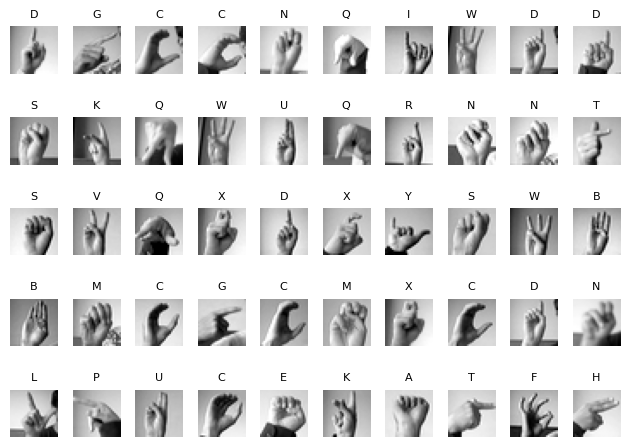

In [ ]:
test_df = pd.read_csv(os.path.join(path, "sign_mnist_test.csv"))
test_df['label'] = test_df['label'].apply(lambda x: chr(x + 65))
y_test = test_df['label']
X_test = test_df.drop(columns=['label'])


X_train = X_train / 255.0
X_test = X_test / 255.0

fig, ax = plt.subplots(5, 10)
axes = ax.flatten()
for i in range(50):
    image = X_train.iloc[i].values.reshape(28, 28)
    axes[i].imshow(image, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(y_train[i], fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
clf = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    random_state=1,
    verbose=True
)

clf.fit(X_train, y_train)

# Evaluate
score = clf.score(X_test, y_test)
print("Accuracy: ", score)

[LibSVM]Accuracy:  0.8371444506413832


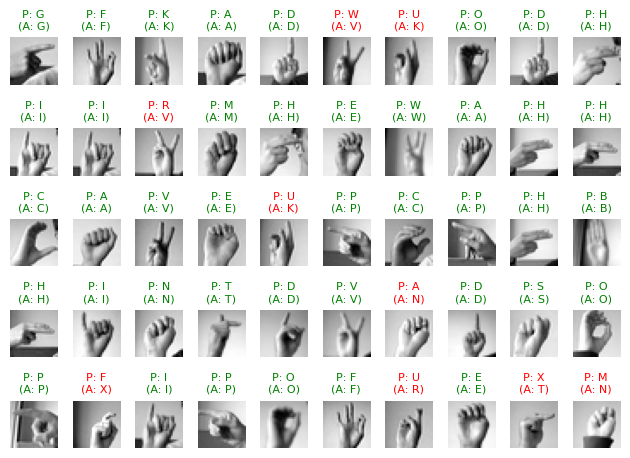

In [ ]:
y_pred = clf.predict(X_test)

fig2, ax2 = plt.subplots(5, 10)
axes2 = ax2.flatten()
for i in range(50):
    image = X_test.iloc[i].values.reshape(28, 28)
    axes2[i].imshow(image, cmap='gray')
    axes2[i].axis('off')

    actual = y_test.iloc[i]
    prediction = y_pred[i]
    color = 'green' if str(actual) == str(prediction) else 'red'

    axes2[i].set_title(f"P: {prediction}\n(A: {actual})", fontsize=8, color=color)

plt.tight_layout()
plt.show()

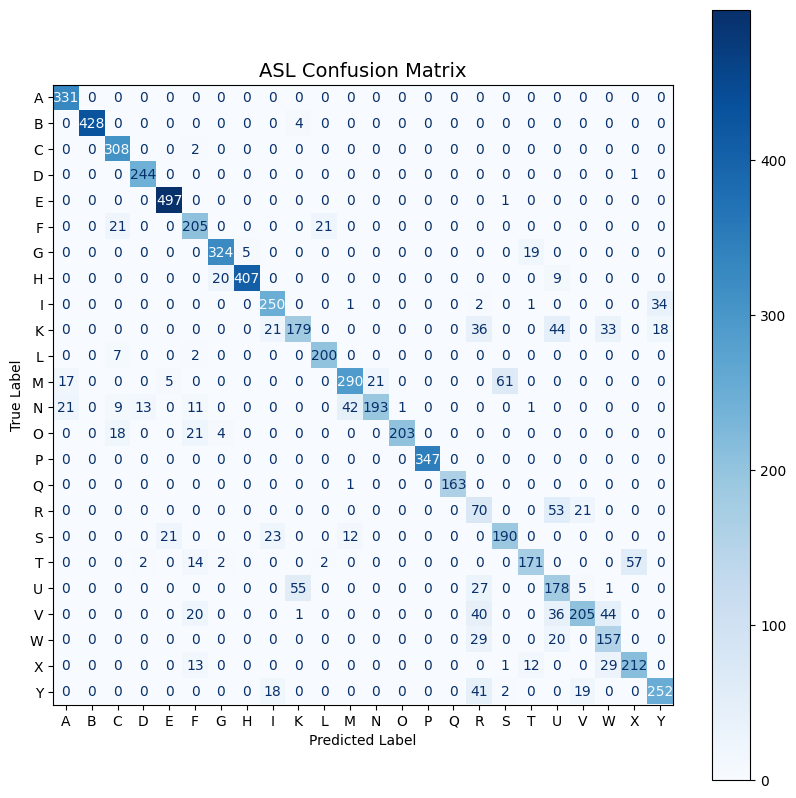

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, colorbar=True)

plt.title("ASL Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.90      1.00      0.95       331
           B       1.00      0.99      1.00       432
           C       0.85      0.99      0.92       310
           D       0.94      1.00      0.97       245
           E       0.95      1.00      0.97       498
           F       0.71      0.83      0.77       247
           G       0.93      0.93      0.93       348
           H       0.99      0.93      0.96       436
           I       0.80      0.87      0.83       288
           K       0.75      0.54      0.63       331
           L       0.90      0.96      0.93       209
           M       0.84      0.74      0.78       394
           N       0.90      0.66      0.76       291
           O       1.00      0.83      0.90       246
           P       1.00      1.00      1.00       347
           Q       1.00      0.99      1.00       164
           R       0.29      0.49      0.36       144
           S       0.75    